In [1]:
import cv2

## 이미지 읽기

In [4]:
img = cv2.imread('cat.jpg')
cv2.imshow('img', img)
cv2.waitKey()
cv2.destroyAllWindows()

## 흑백으로 이미지 읽기

In [5]:
img = cv2.imread('pier39.jpg', flags=cv2.IMREAD_GRAYSCALE)
cv2.imshow('img', img)
cv2.waitKey()
cv2.destroyAllWindows()

In [6]:
img1 = cv2.imread('pier39.jpg', flags=cv2.IMREAD_COLOR)
img2 = cv2.imread('pier39.jpg', flags=cv2.IMREAD_GRAYSCALE)

print('type(img1):',type(img1))
print('img1.dtype:',img1.dtype)
print('img1.shape:',img1.shape)
print('img2.shape:',img2.shape)
h, w = img2.shape[:2]
print('img2.size: {} x {}'.format(w,h))

cv2.imshow('img1', img1)
cv2.imshow('img2', img2)
cv2.moveWindow('img2', 400,200) # 기존의 출력되는 윈도우의 위치 이동

cv2.waitKey()
cv2.destroyAllWindows()

type(img1): <class 'numpy.ndarray'>
img1.dtype: uint8
img1.shape: (480, 640, 3)
img2.shape: (480, 640)
img2.size: 640 x 480


## 화소를 슬라이싱 기법으로 배열에 기록

In [7]:
img1 = cv2.imread('cat.jpg', flags=cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('cat.jpg', flags=cv2.IMREAD_COLOR)
h, w = img2.shape[:2]
print('img1.shape:',img1.shape)
print('img2.shape:',img2.shape)

for y in range(300, h):
    for x in range(300, w):
        img1[y,x] = 255
        img2[y,x] = (0,0,255)

img1[300:640, 300:640] = 255
img2[300:640, 300:640] = (0,0,255)

cv2.imshow('img1', img1)
cv2.imshow('img2', img2)

cv2.waitKey()
cv2.destroyAllWindows()

img1.shape: (640, 640)
img2.shape: (640, 640, 3)


## 영상 밝기 조절

In [8]:
src = cv2.imread('pier39.JPG', cv2.IMREAD_GRAYSCALE)

dst1 = src + 100
dst2 = cv2.add(src, 100)
cv2.imshow('src', src) # 원본
cv2.imshow('dst1', dst1) # 255를 넘는 밝기는 255를 뺀 0부터 이어서 시작하므로 밝은 이미지는 어두워질 수 있음
cv2.imshow('dst2', dst2) # 포화 연산을 수행하여 255 밝기를 넘기면 255로 고정되므로 하얀색이 되면 더 밝아지지 않음

cv2.waitKey()
cv2.destroyAllWindows()

## 컬러 영상 밝기 조절

In [9]:
src = cv2.imread('pier39.JPG')

dst = cv2.add(src, (100,100,100,0)) # 채널별로 100씩 덧셈
cv2.imshow('src', src) # 원본
cv2.imshow('dst', dst) # 255를 넘는 밝기는 255를 뺀 0부터 이어서 시작하므로 밝은 이미지는 어두워질 수 있음

cv2.waitKey()
cv2.destroyAllWindows()

In [10]:
src1 = cv2.imread('cat.jpg')
src2 = cv2.imread('dog.jpg')

dst = cv2.add(src1, src2)
cv2.imshow('src1', src1)
cv2.imshow('src2', src2)
cv2.imshow('dst', dst)
cv2.waitKey()
cv2.destroyAllWindows()

## 가중치 합

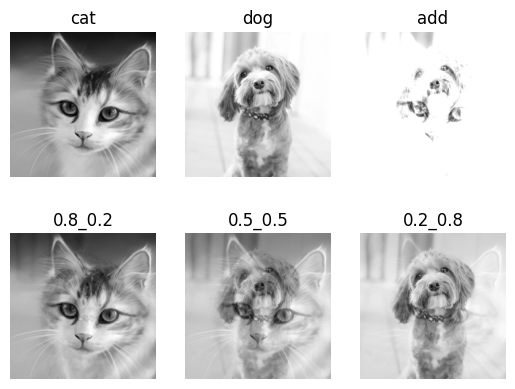

In [2]:
import matplotlib.pyplot as plt

src1 = cv2.imread('cat.jpg', cv2.IMREAD_GRAYSCALE)
src2 = cv2.imread('dog.jpg', cv2.IMREAD_GRAYSCALE)

dst1 = cv2.add(src1, src2)
dst2 = cv2.addWeighted(src1, 0.8, src2, 0.2, 0)
dst3 = cv2.addWeighted(src1, 0.5, src2, 0.5, 0)
dst4 = cv2.addWeighted(src1, 0.2, src2, 0.8, 0)

plt.subplot(231), plt.axis('off'), plt.imshow(src1, 'gray'), plt.title('cat')
plt.subplot(232), plt.axis('off'), plt.imshow(src2, 'gray'), plt.title('dog')
plt.subplot(233), plt.axis('off'), plt.imshow(dst1, 'gray'), plt.title('add')
plt.subplot(234), plt.axis('off'), plt.imshow(dst2, 'gray'), plt.title('0.8_0.2')
plt.subplot(235), plt.axis('off'), plt.imshow(dst3, 'gray'), plt.title('0.5_0.5')
plt.subplot(236), plt.axis('off'), plt.imshow(dst4, 'gray'), plt.title('0.2_0.8')
plt.show()

## 뺄셈 연산

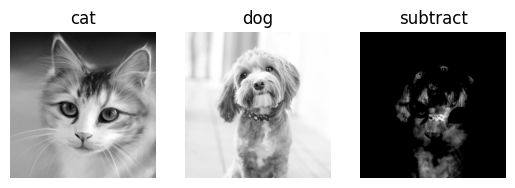

In [12]:
src1 = cv2.imread('cat.jpg', cv2.IMREAD_GRAYSCALE)
src2 = cv2.imread('dog.jpg', cv2.IMREAD_GRAYSCALE)

src1 = cv2.resize(src1, (500, 500))
src2 = cv2.resize(src2, (500, 500))

dst = cv2.subtract(src1, src2)

plt.subplot(131), plt.axis('off'), plt.imshow(src1, 'gray'), plt.title('cat')
plt.subplot(132), plt.axis('off'), plt.imshow(src2, 'gray'), plt.title('dog')
plt.subplot(133), plt.axis('off'), plt.imshow(dst, 'gray'), plt.title('subtract')
plt.show()

## 차이 연산

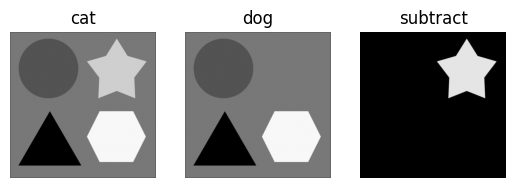

In [13]:
src1 = cv2.imread('abs1.jpg', cv2.IMREAD_GRAYSCALE)
src2 = cv2.imread('abs2.jpg', cv2.IMREAD_GRAYSCALE)

dst = cv2.absdiff(src1, src2)

plt.subplot(131), plt.axis('off'), plt.imshow(src1, 'gray'), plt.title('cat')
plt.subplot(132), plt.axis('off'), plt.imshow(src2, 'gray'), plt.title('dog')
plt.subplot(133), plt.axis('off'), plt.imshow(dst, 'gray'), plt.title('subtract')
plt.show()

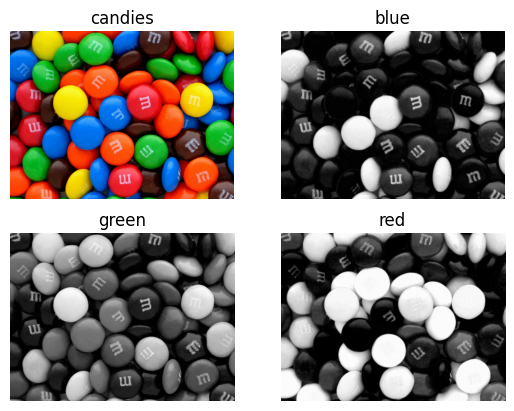

In [14]:
src = cv2.imread('candies.png')

b,g,r = cv2.split(src) # 채널 분리

merge_b = cv2.merge([b,b,b])
merge_g = cv2.merge([g,g,g])
merge_r = cv2.merge([r,r,r])

plt.subplot(221), plt.axis('off'), plt.imshow(cv2.cvtColor(src, cv2.COLOR_BGR2RGB)), plt.title('candies')
plt.subplot(222), plt.axis('off'), plt.imshow(merge_b, 'gray'), plt.title('blue')
plt.subplot(223), plt.axis('off'), plt.imshow(merge_g, 'gray'), plt.title('green')
plt.subplot(224), plt.axis('off'), plt.imshow(merge_r, 'gray'), plt.title('red')
plt.show()

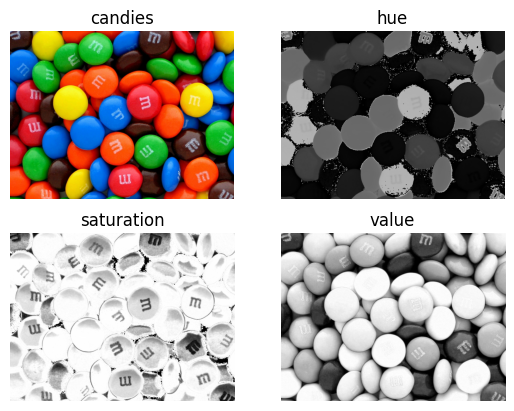

In [15]:
src = cv2.imread('candies.png')
hsv = cv2.cvtColor(src, cv2.COLOR_BGR2HSV)
h,s,v = cv2.split(hsv) # 적응시 훨씬 직관적이라고 함

merge_h = cv2.merge([h,h,h])
merge_s = cv2.merge([s,s,s])
merge_v = cv2.merge([v,v,v])

plt.subplot(221), plt.axis('off'), plt.imshow(cv2.cvtColor(src, cv2.COLOR_BGR2RGB)), plt.title('candies')
plt.subplot(222), plt.axis('off'), plt.imshow(merge_h, 'gray'), plt.title('hue') # 색상(0~179)
plt.subplot(223), plt.axis('off'), plt.imshow(merge_s, 'gray'), plt.title('saturation') # 채도(0~255)
plt.subplot(224), plt.axis('off'), plt.imshow(merge_v, 'gray'), plt.title('value') # 명도(0~255)
plt.show()

# 히스토그램

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

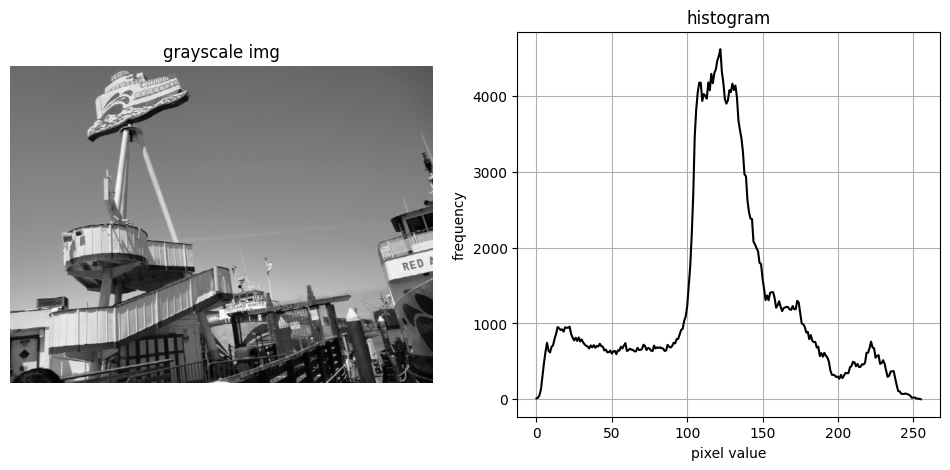

In [17]:
img = cv2.imread('pier39.JPG', cv2.IMREAD_GRAYSCALE)
hist = cv2.calcHist([img], [0], None, [256], [0,256])
plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(img, 'gray')
plt.title('grayscale img')
plt.axis('off')

plt.subplot(122)
plt.plot(hist, color='black')
plt.title('histogram')
plt.xlabel('pixel value')
plt.ylabel('frequency')
plt.grid(True)
plt.show()

In [18]:
# rgb는 이미지를 보이는대로 보여주기 위함
# 반면, hsv는 객관적 색상을 보여주는 것임
# ex) 이미지 자체만을 보여주고자 할 때 -> RGB
#     정확한 이미지의 분류 및 검출 등(색상 추출등) -> HSV

## 컬러 영상의 히스토그램

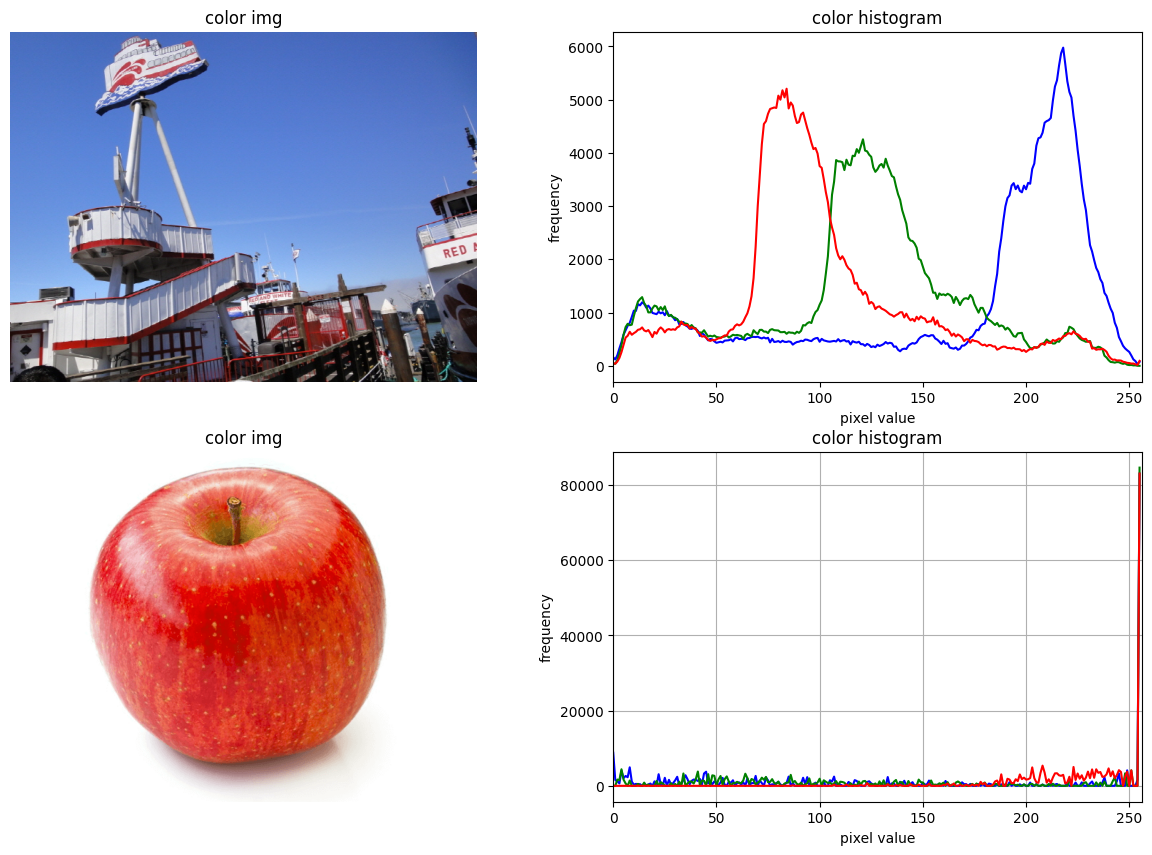

In [25]:
img = cv2.imread('pier39.JPG')
img2 = cv2.imread('apple.png')
channels = tuple('bgr')
colors = ('blue','green','red')

plt.figure(figsize=(15,10))
plt.subplot(221)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGRA))
plt.title('color img')
plt.axis('off')

plt.subplot(222)
for i, color in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0,256])
    plt.plot(hist, color)
    plt.xlim([0,256])
plt.title('color histogram')
plt.xlabel('pixel value')
plt.ylabel('frequency')

plt.subplot(223)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_RGB2BGRA))
plt.title('color img')
plt.axis('off')

plt.subplot(224)
for i, color in enumerate(colors):
    hist = cv2.calcHist([img2], [i], None, [256], [0,256])
    plt.plot(hist, color)
    plt.xlim([0,256])
plt.title('color histogram')
plt.xlabel('pixel value')
plt.ylabel('frequency')


plt.grid(True)
plt.show()

위의 히스토그램에서 선이 한쪽으로만 치솟으면 이미지를 잘못 찍은 것임. 예시로 사과 이미지의 경우가 그러함

## 명암비 조절
- 명암비는 픽셀값을 조정하며 128(기준값)을 기준으로 조절함

In [26]:
src = cv2.imread('dog.jpg', cv2.IMREAD_GRAYSCALE)

# cv2는 데이터를 ndarray로 인식하므로 np연산을 하면 됨
alpha = 1.0
dst = np.clip((1+alpha)*src - 128*alpha, 0, 255).astype(np.uint8) 

cv2.imshow('src', src)
cv2.imshow('dst', dst)

cv2.waitKey()
cv2.destroyAllWindows()

## 명암비 정규화

In [67]:
src = cv2.imread('Hawkes_Bays.jpg', cv2.IMREAD_GRAYSCALE)
dst = cv2.normalize(src, None, 0, 255, cv2.NORM_MINMAX) # 히스토그램 스트레칭
cv2.imshow('src', src) 
cv2.imshow('dst', dst)
cv2.waitKey()
cv2.destroyAllWindows()

## 히스토그램 평활화

In [ ]:
scr = cv2.imread('Hawkes_Bays.jpg', cv2.IMREAD_GRAYSCALE)
dst = cv2.equalizeHist(src)

cv2.imshow('src', scr)
cv2.imshow('dst', dst)
cv2.waitKey()
cv2.destroyAllWindows()

# 복습 문제

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

### 단순 컬러 이미지 연산

In [ ]:
img = cv2.imread('apple.png')
np_dst = img + 100
cv_dst = cv2.add(img, 100)
cv2.imshow('np_dst',np_dst)
cv2.imshow('cv_dst',cv_dst)
cv2.waitKey()
cv2.destroyAllWindows()

### 흑백 이미지 연산

In [14]:
img = cv2.imread('apple.png', cv2.IMREAD_GRAYSCALE)
np_dst = img + 100
cv_dst = cv2.add(img, 100)
cv2.imshow('np_dst',np_dst)
cv2.imshow('cv_dst',cv_dst)
cv2.waitKey()
cv2.destroyAllWindows()

### 가중치 연산

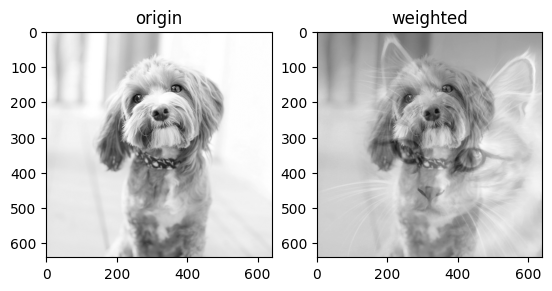

In [30]:
img1 = cv2.imread('dog.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('cat.jpg', cv2.IMREAD_GRAYSCALE)
dst = cv2.addWeighted(img1, 0.6, img2, beta=0.4, gamma=0)
plt.subplot(121)
plt.imshow(img1, 'gray')
plt.title('origin')
plt.subplot(122)
plt.title('weighted')
plt.imshow(dst, 'gray')

### np.clip을 이용한 밝기 조절(src+n과 같은 결과 나옴)

In [ ]:
src = cv2.imread('apple.png')
dst = np.clip(src+20, 0, 255)
cv2.imshow('dst',dst)
cv2.waitKey()
cv2.destroyAllWindows()

uint8


### B, G, R을 분리하여 시각화

In [51]:
img = cv2.imread('beach.jpg')
b,g,r = cv2.split(img)
img_b = cv2.merge([b,b,b])
img_g = cv2.merge([g,g,g])
img_r = cv2.merge([r,r,r])

cv2.imshow('original',img)
cv2.imshow('b',img_b)
cv2.imshow('g',img_g)
cv2.imshow('r',img_r)
cv2.waitKey()
cv2.destroyAllWindows()

### 이미지의 히스토그램을 구하고 matplotlib로 출력

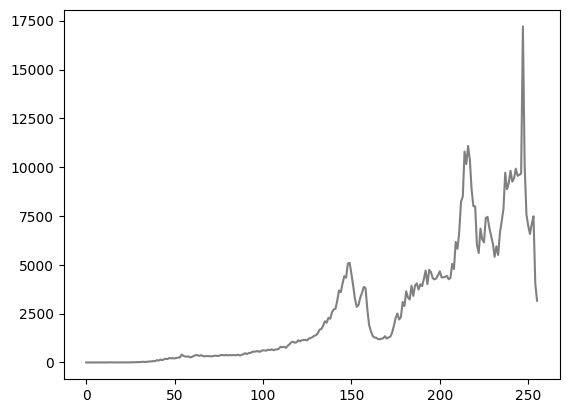

In [66]:
img = cv2.imread('beach.jpg', cv2.IMREAD_GRAYSCALE)
hist = cv2.calcHist([img], [0], None, [256], [0,256])
plt.plot(hist, 'gray')
plt.show()

### 히스토그램 스트레칭 적용, 전후 히스토그램을 비교 

In [68]:
src = cv2.imread('Hawkes_Bays.jpg', cv2.IMREAD_GRAYSCALE)
dst = cv2.normalize(src, None, 0, 255, cv2.NORM_MINMAX) # 히스토그램 스트레칭
cv2.imshow('src', src) 
cv2.imshow('dst', dst)
cv2.waitKey()
cv2.destroyAllWindows()

### 히스토그램 평활화 적용 , 원본과 비교 + 히스토그램 분포도 함께 확인하세요.

In [ ]:
scr = cv2.imread('Hawkes_Bays.jpg', cv2.IMREAD_GRAYSCALE)
dst = cv2.equalizeHist(src)

cv2.imshow('src', scr)
cv2.imshow('dst', dst)
cv2.waitKey()
cv2.destroyAllWindows()